# Airbnb Price Prediction — Exploratory Data Analysis (EDA)

This notebook contains exploratory data analysis (EDA) on New York City Airbnb listing data. 

The goal: to understand the variables affecting price and to examine the data's structure, distributions, and potential problems (missing values, outliers, correlations) before modeling.

**Dataset:** NYC Airbnb Open Data

**Target variable:** `price`

### 1. Loading Libraries

We import the necessary libraries for analysis: `pandas`/`numpy` for data processing,
`matplotlib`/`seaborn` for visualization. We also adjust the pandas display settings to make decimal numbers appear more readable with 3 digits.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
from pathlib import Path


pd.set_option("display.float_format", "{:.3f}".format)

### 2. Configuration and Data Loading

Instead of writing file paths as hardcoded elements, we read them from a `config.yaml` file. This allows you to simply modify the config file when the project is run on a different computer — no need to touch the code itself. This makes the project more organized and reusable.

In [3]:
def load_config(config_path):
    with open(config_path, "r") as f:
        config = yaml.safe_load(f)
    return config

In [4]:
base_path = Path.cwd().parent
config_path = base_path / "config" / "config.yaml"
cfg = load_config(config_path)
data_path = cfg["paths"]["raw_path"]

In [5]:
df = pd.read_csv(base_path / data_path)

### 3. First Look at the Data

Using `head()`, we get a general overview of what the columns contain and the data types by viewing the first rows.

In [6]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.647,-73.972,Private room,149,1,9,2018-10-19,0.210,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.754,-73.984,Entire home/apt,225,1,45,2019-05-21,0.380,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.809,-73.942,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.685,-73.960,Entire home/apt,89,1,270,2019-07-05,4.640,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.799,-73.944,Entire home/apt,80,10,9,2018-11-19,0.100,1,0


### 4. Removing Unnecessary Columns

The columns `id`, `name`, `host_id`, and `host_name` do not carry any meaningful information for price estimation (ID and name fields).
We remove these columns to simplify the analysis.

In [7]:
drop_cols = ["id", "name", "host_id", "host_name"]
df = df.drop(drop_cols, axis=1)

### 5. General Structure and Quality Control of Data

In this section, we check the health of the data:
- `shape` → number of rows and columns
- `info()` → data types and non-null values
- `isnull().sum()` → number of missing values ​​in each column
- `duplicated().sum()` → are there any duplicate rows?
- `describe()` → basic statistics of numerical columns (average, min, max, etc.)


>**Notes:** The dataset has 48,895 rows and 12 columns.
>There are 10,052 missing values ​​in the `reviews_per_month` and `last_review` columns. These are most likely from ads that >have not received any reviews.
>The very high maximum values ​​in the `price` column indicate that there may be outliers.

In [8]:
df.shape

(48895, 12)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   neighbourhood_group             48895 non-null  object 
 1   neighbourhood                   48895 non-null  object 
 2   latitude                        48895 non-null  float64
 3   longitude                       48895 non-null  float64
 4   room_type                       48895 non-null  object 
 5   price                           48895 non-null  int64  
 6   minimum_nights                  48895 non-null  int64  
 7   number_of_reviews               48895 non-null  int64  
 8   last_review                     38843 non-null  object 
 9   reviews_per_month               38843 non-null  float64
 10  calculated_host_listings_count  48895 non-null  int64  
 11  availability_365                48895 non-null  int64  
dtypes: float64(3), int64(5), object(

In [10]:
df.isnull().sum()

neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
latitude,48895.000,40.729,0.055,40.500,40.690,40.723,40.763,40.913
longitude,48895.000,-73.952,0.046,-74.244,-73.983,-73.956,-73.936,-73.713
price,48895.000,152.721,240.154,0.000,69.000,106.000,175.000,10000.000
minimum_nights,48895.000,7.030,20.511,1.000,1.000,3.000,5.000,1250.000
number_of_reviews,48895.000,23.274,44.551,0.000,1.000,5.000,24.000,629.000
reviews_per_month,38843.000,1.373,1.680,0.010,0.190,0.720,2.020,58.500
calculated_host_listings_count,48895.000,7.144,32.953,1.000,1.000,1.000,2.000,327.000
availability_365,48895.000,112.781,131.622,0.000,0.000,45.000,227.000,365.000


### 6. Distribution of the Target Variable (price)

We examine the price distribution using a histogram and boxplot. We applied a `price < 1000` filter because very extreme values ​​make the graph unreadable.

> **Observation:** The price distribution is skewed to the right; most listings are clustered in the low-to-medium price range, with a small number of very expensive listings. These outliers should be addressed during the modeling phase (e.g., log transformation).

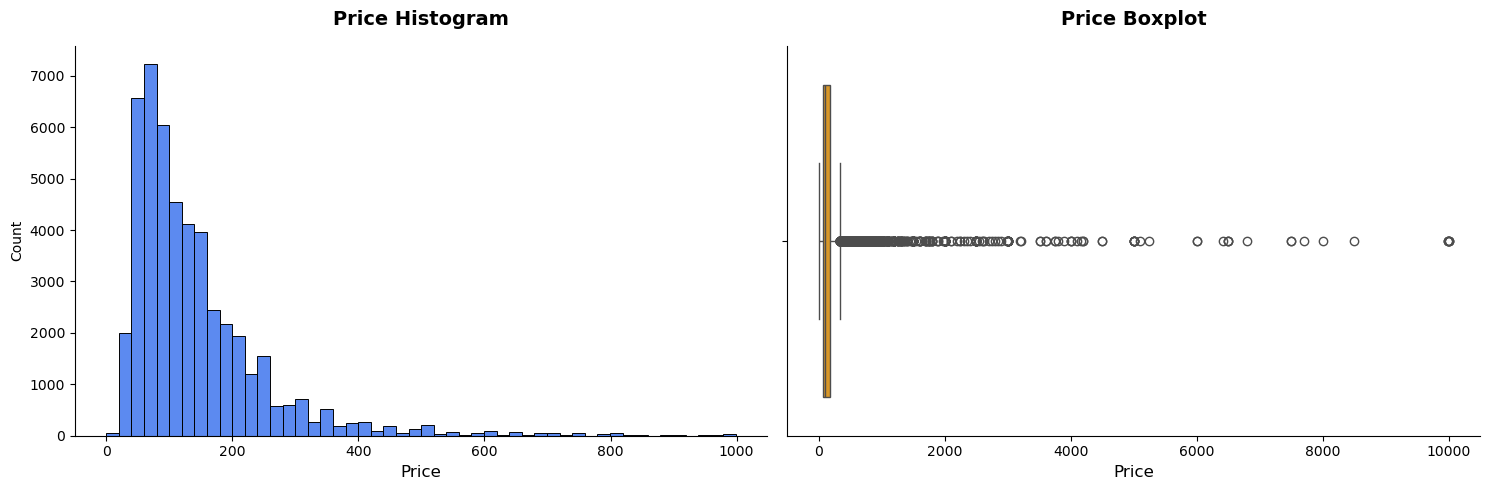

In [13]:
filtered = df[df["price"] < 1000]

fig, ax = plt.subplots(1,2, figsize=(15,5))
sns.histplot(data=filtered, x="price", bins=50, color="#2563EB", ax=ax[0])
sns.despine(ax=ax[0])
ax[0].set_title("Price Histogram", fontsize=14, fontweight="bold", pad=15)
ax[0].set_xlabel("Price", fontsize=12)


sns.boxplot(data=df, x="price", color="#F59E0B", ax=ax[1])
sns.despine(ax=ax[1])
ax[1].set_title("Price Boxplot", fontsize=14, fontweight="bold", pad=15)
ax[1].set_xlabel("Price", fontsize=12)

plt.tight_layout()
plt.show()

In [14]:
(df["price"] <= 0).sum()

np.int64(11)

### 7. Examining Categorical Variables

We look at how many times the categories in the `neighbourhood`, `room_type`, and `neighbourhood_group` columns appear. This allows us to understand which areas and room types are more common.

In [15]:
df["neighbourhood"].value_counts()

neighbourhood
Williamsburg          3920
Bedford-Stuyvesant    3714
Harlem                2658
Bushwick              2465
Upper West Side       1971
                      ... 
Richmondtown             1
Fort Wadsworth           1
New Dorp                 1
Rossville                1
Willowbrook              1
Name: count, Length: 221, dtype: int64

In [16]:
df["room_type"].value_counts()

room_type
Entire home/apt    25409
Private room       22326
Shared room         1160
Name: count, dtype: int64

In [17]:
df["neighbourhood_group"].value_counts()

neighbourhood_group
Manhattan        21661
Brooklyn         20104
Queens            5666
Bronx             1091
Staten Island      373
Name: count, dtype: int64

### 8. Neighborhoods with the Most Listings

We are visualizing the 15 neighborhoods with the highest number of listings.

> **Observation:** Neighborhoods like Williamsburg and Bedford-Stuyvesant stand out in terms of the number of listings; these areas may be tourist/high-demand locations.

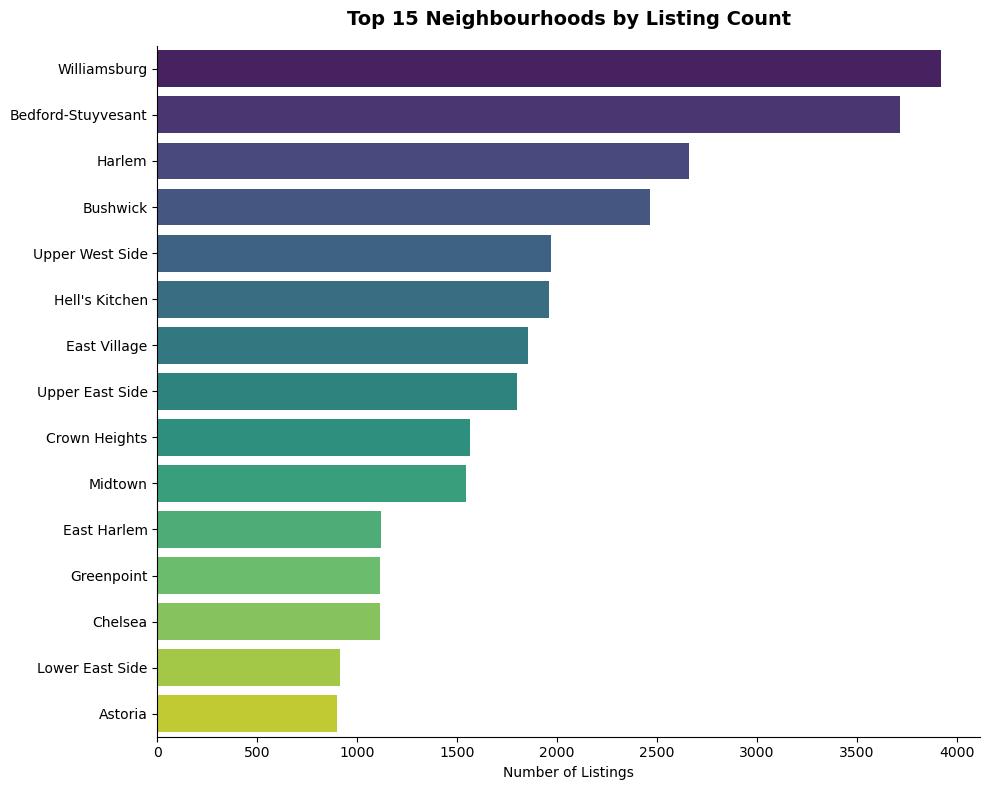

In [18]:
top_n = df["neighbourhood"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10,8))
sns.barplot(x=top_n.values, y=top_n.index, hue=top_n.index, palette="viridis", legend=False, ax=ax)
sns.despine(ax=ax)
ax.set_title("Top 15 Neighbourhoods by Listing Count",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Number of Listings")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

### 9. District (Neighbourhood Group) Analysis

We examine districts from three perspectives: number of listings, price distribution, and the breakdown of room types by district.

> **Observation:** Manhattan stands out in both the number of listings and price level. > This indicates that location (district) can be a strong variable influencing price.

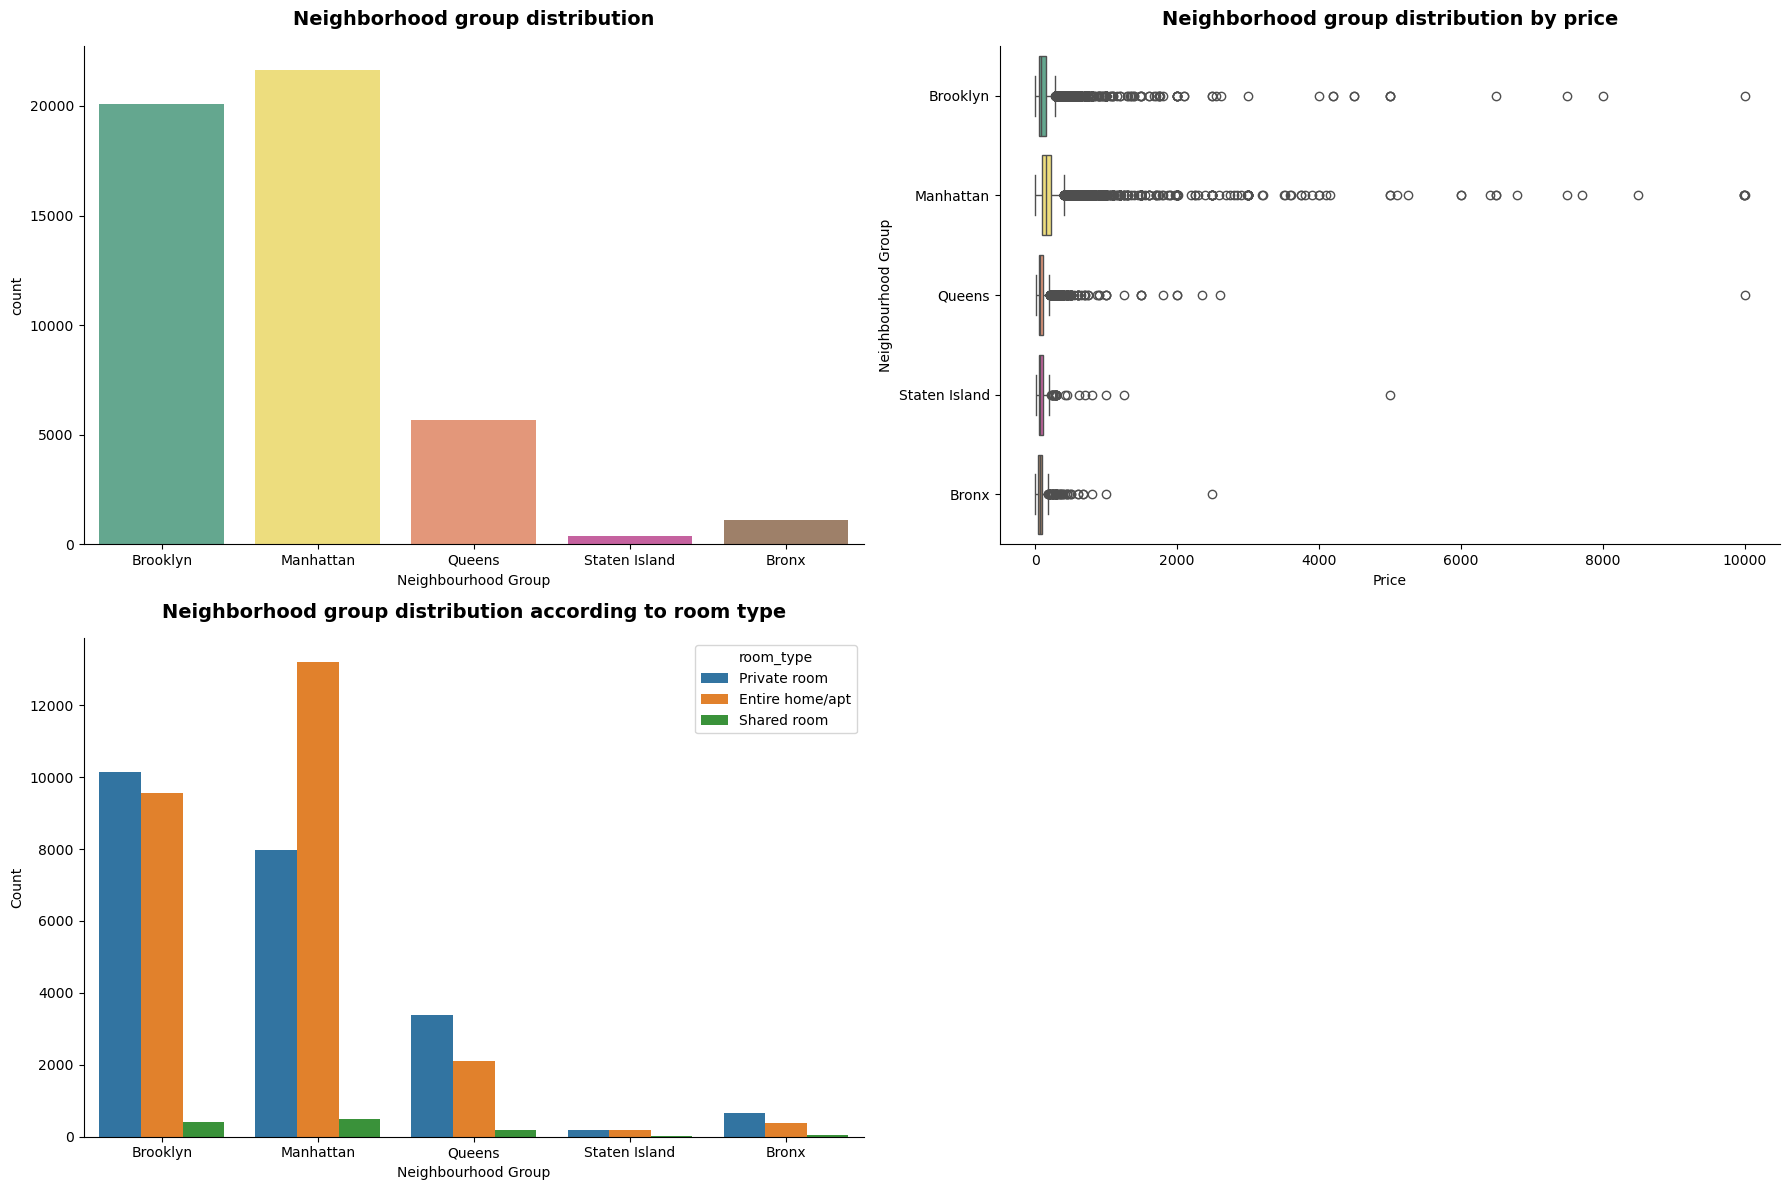

In [19]:
palettes = ["#59B292", "#FFEA6C", "#F48F68", "#D552A3", "#A77F60"]

fig, ax = plt.subplots(2, 2,figsize=(18,12))
sns.countplot(data=df, x="neighbourhood_group", hue="neighbourhood_group", palette=palettes, legend=False, ax=ax[0, 0])
sns.despine(ax=ax[0, 0])
ax[0, 0].set_title("Neighborhood group distribution", fontsize=14, fontweight="bold", pad=15)
ax[0, 0].set_xlabel("Neighbourhood Group")

sns.boxplot(data=df, x="price", y="neighbourhood_group", hue="neighbourhood_group", palette=palettes, legend=False, ax=ax[0 ,1])
sns.despine(ax=ax[0, 1])
ax[0, 1].set_title("Neighborhood group distribution by price", fontsize=14, fontweight="bold", pad=15)
ax[0, 1].set_xlabel("Price")
ax[0, 1].set_ylabel("Neighbourhood Group")

sns.countplot(data=df, x="neighbourhood_group", hue="room_type", ax=ax[1, 0])
sns.despine(ax=ax[1, 0])
ax[1, 0].set_title("Neighborhood group distribution according to room type", fontsize=14, fontweight="bold", pad=15)
ax[1, 0].set_xlabel("Neighbourhood Group")
ax[1, 0].set_ylabel("Count")


ax[1, 1].axis("off")

plt.tight_layout()
plt.show()

### 10. Room Type and Price Relationship

We examine the proportional distribution (pie chart) of room types and the price distribution (boxplot) of each room type.

> **Observation:** As expected, "Entire home/apt" type listings are in the highest price range; "Shared room" is the lowest. Room type is an important distinguishing variable for price.

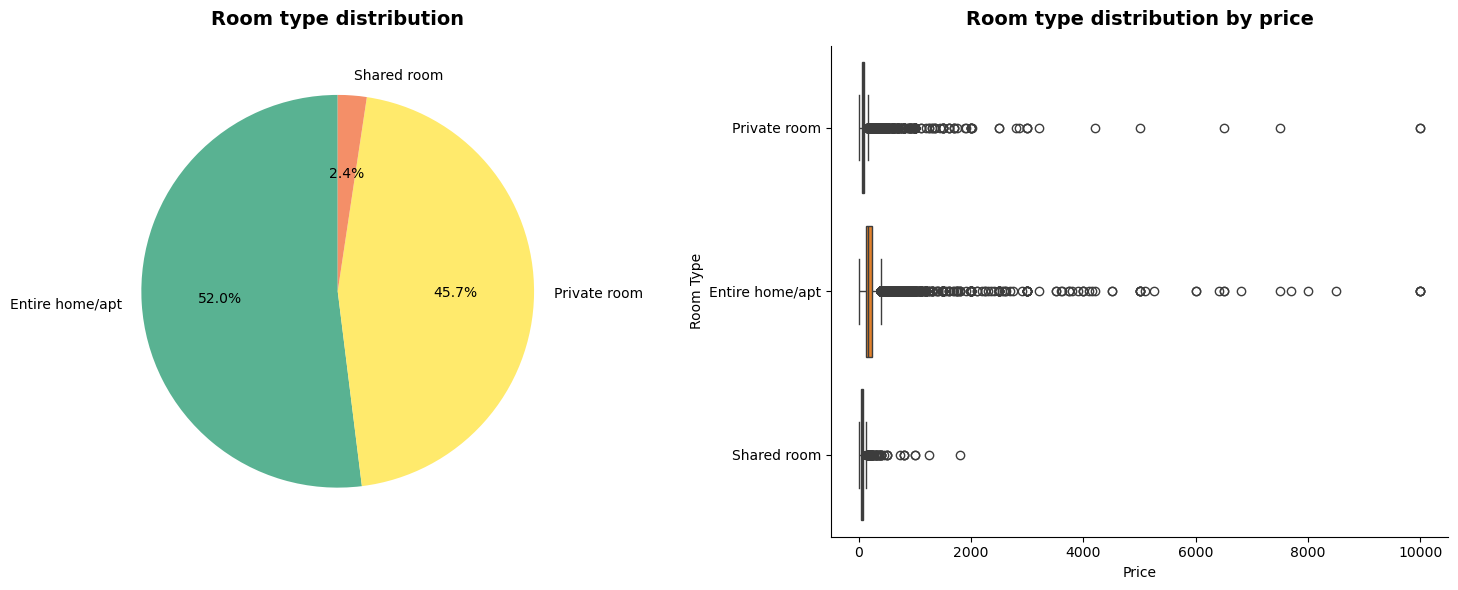

In [20]:
fig, ax = plt.subplots(1,2,figsize=(15,6))

room_type_counts = df["room_type"].value_counts()

ax[0].pie(
    room_type_counts,
    labels=room_type_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=palettes
)

ax[0].set_title("Room type distribution", fontsize=14, fontweight="bold", pad=15)


sns.boxplot(data=df, x="price", y="room_type", hue="room_type", ax=ax[1])
sns.despine(ax=ax[1])
ax[1].set_title("Room type distribution by price", fontsize=14, fontweight="bold", pad=15)
ax[1].set_xlabel("Price")
ax[1].set_ylabel("Room Type")


plt.tight_layout()
plt.show()

### 11. Geographic Distribution

We display the advertisements in a map-like distribution using latitude and longitude information.
Colors are used to differentiate between regions. This visualizes the density of advertisements within the city.

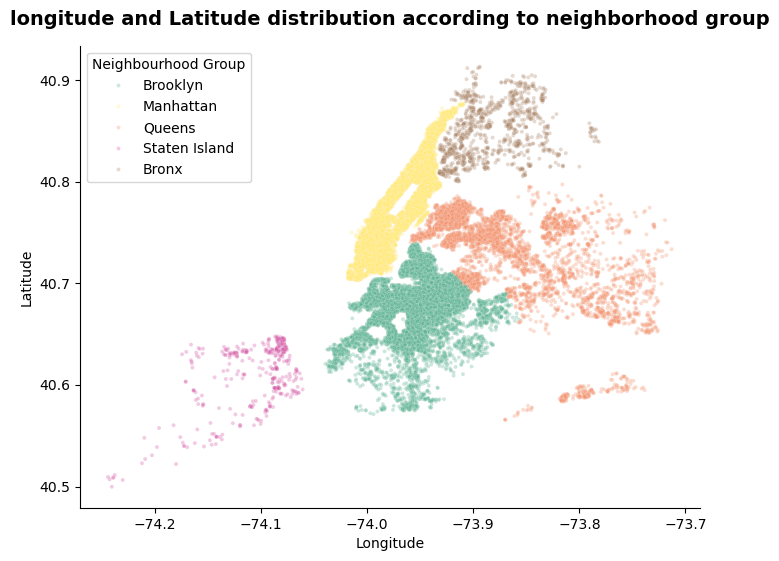

In [21]:
fig, ax = plt.subplots(figsize=(8,6))

sns.scatterplot(
    data=df, 
    x="longitude", 
    y="latitude", 
    hue="neighbourhood_group", 
    palette=palettes, 
    alpha=0.3, 
    s=8, 
    ax=ax)

sns.despine(ax=ax)

ax.set_title(
    "longitude and Latitude distribution according to neighborhood group", 
    fontsize=14, 
    fontweight="bold", 
    pad=15)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

ax.legend(
    title="Neighbourhood Group",
    loc="upper left"
)

plt.show()

### 12. Minimum Stay Duration (minimum_nights)

We are examining the distribution of the minimum number of nights. To filter out excessively high values, we applied the filter
`minimum_nights < 400`.

> **Observation:** The vast majority of listings request a minimum stay of a few days;
> a small number of listings requesting very long stays are outliers.

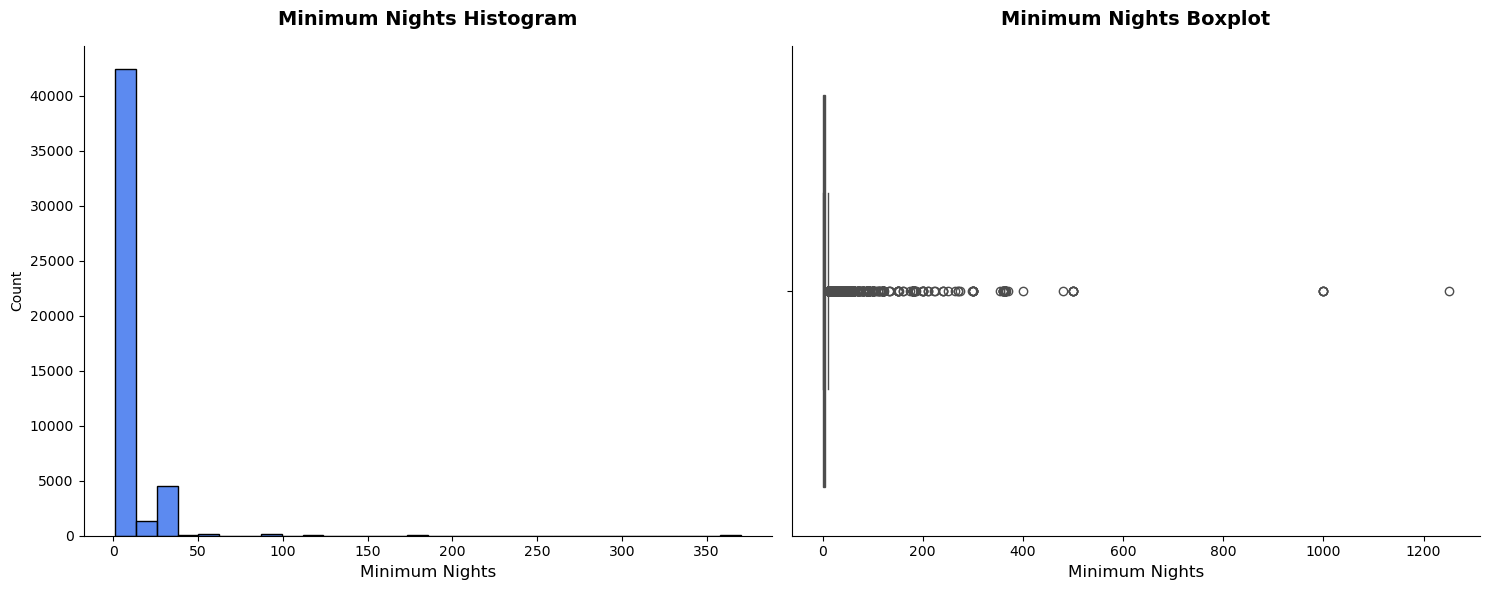

In [22]:
filtered = df[df["minimum_nights"] < 400]

fig, ax = plt.subplots(1,2,figsize=(15,6))

sns.histplot(data=filtered, x="minimum_nights", bins=30, color="#2563EB", ax=ax[0])
sns.despine(ax=ax[0])
ax[0].set_title("Minimum Nights Histogram", fontsize=14, fontweight="bold", pad=15)
ax[0].set_xlabel("Minimum Nights", fontsize=12)


sns.boxplot(data=df, x="minimum_nights", color="#F59E0B", ax=ax[1])
sns.despine(ax=ax[1])
ax[1].set_title("Minimum Nights Boxplot", fontsize=14, fontweight="bold", pad=15)
ax[1].set_xlabel("Minimum Nights", fontsize=12)

plt.tight_layout()
plt.show()

### 13. Relationship Between Review and Host Variables and Price

We examine the relationship between the number of reviews, the monthly number of reviews, and the number of listings owned by a host and price using scatter plots.

> **Observation:** There does not appear to be a clear linear relationship between the number of reviews and price; the number of reviews may reflect popularity rather than price.

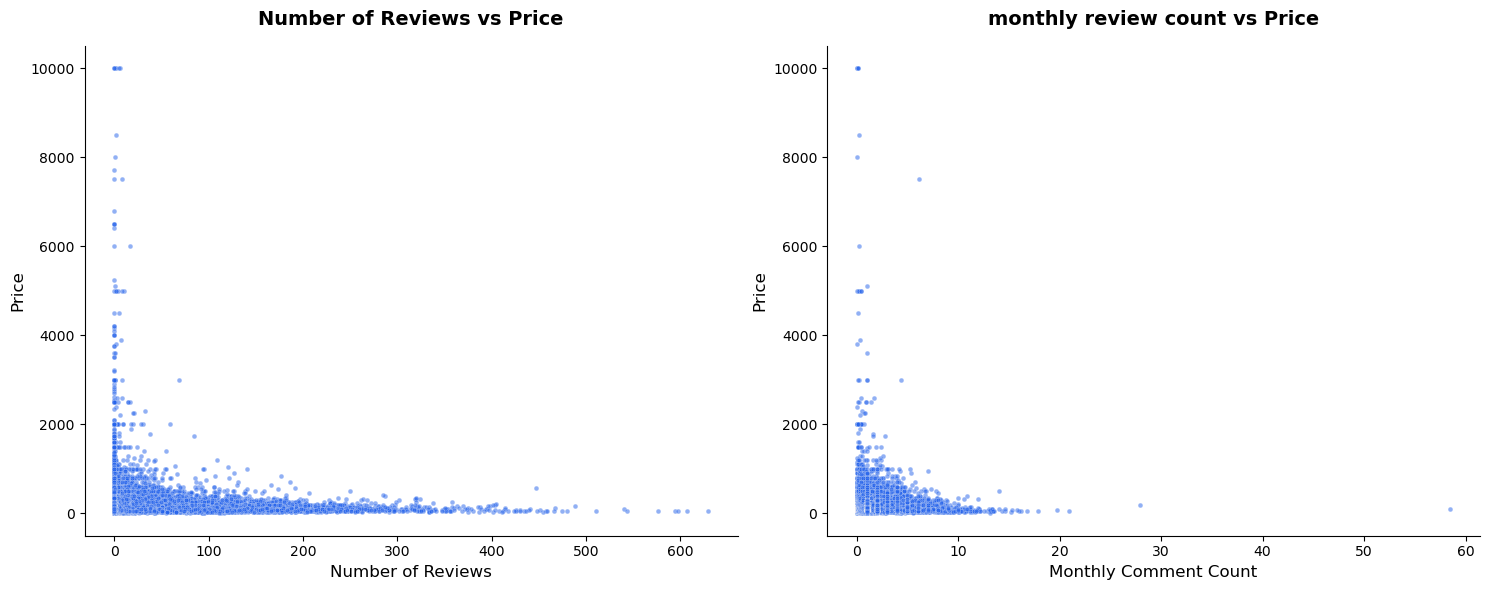

In [23]:
fig, ax = plt.subplots(1,2,figsize=(15,6))
sns.scatterplot(data=df, x="number_of_reviews", y="price", alpha=0.5, s=12, color="#2563EB", ax=ax[0])
sns.despine(ax=ax[0])
ax[0].set_title("Number of Reviews vs Price", fontsize=14, fontweight="bold", pad=15)
ax[0].set_xlabel("Number of Reviews", fontsize=12)
ax[0].set_ylabel("Price", fontsize=12)

sns.scatterplot(data=df, x="reviews_per_month", y="price", alpha=0.5, s=12, color="#2563EB", ax=ax[1])
sns.despine(ax=ax[1])
ax[1].set_title("monthly review count vs Price", fontsize=14, fontweight="bold", pad=15)
ax[1].set_xlabel("Monthly Comment Count", fontsize=12)
ax[1].set_ylabel("Price", fontsize=12)

plt.tight_layout()
plt.show()

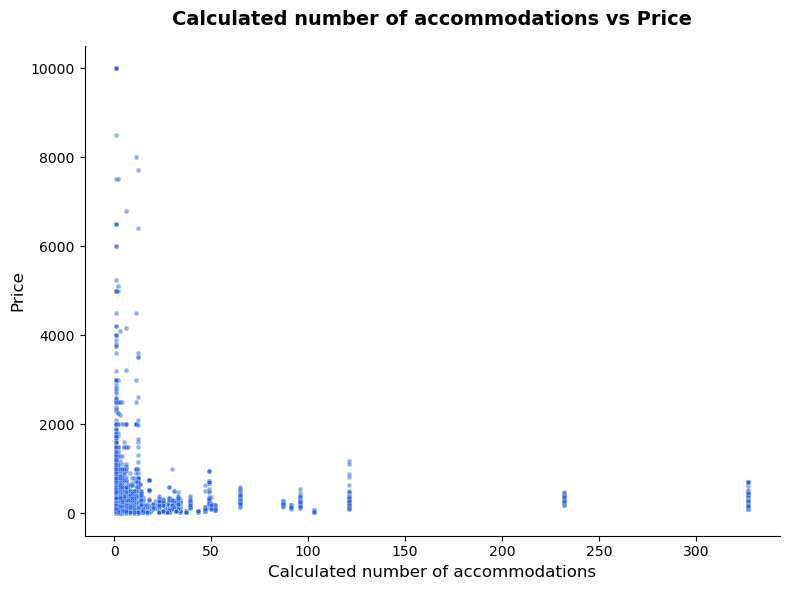

In [24]:
fig, ax = plt.subplots(figsize=(8,6))

sns.scatterplot(data=df, x="calculated_host_listings_count", y="price", alpha=0.5, s=12, color="#2563EB", ax=ax)
sns.despine(ax=ax)
plt.title("Calculated number of accommodations vs Price", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Calculated number of accommodations", fontsize=12)
plt.ylabel("Price", fontsize=12)

plt.tight_layout()
plt.show()

### 14. Correlation Matrix

We show the correlation between numerical variables with a heat map. This helps us understand which
variables are more strongly related to price and whether there is high
correlation (multicollinearity) between variables.

> **Observation:** The correlation of numerical variables with price is generally low;
> this suggests that price is largely explained by categorical variables (room type, region).
>

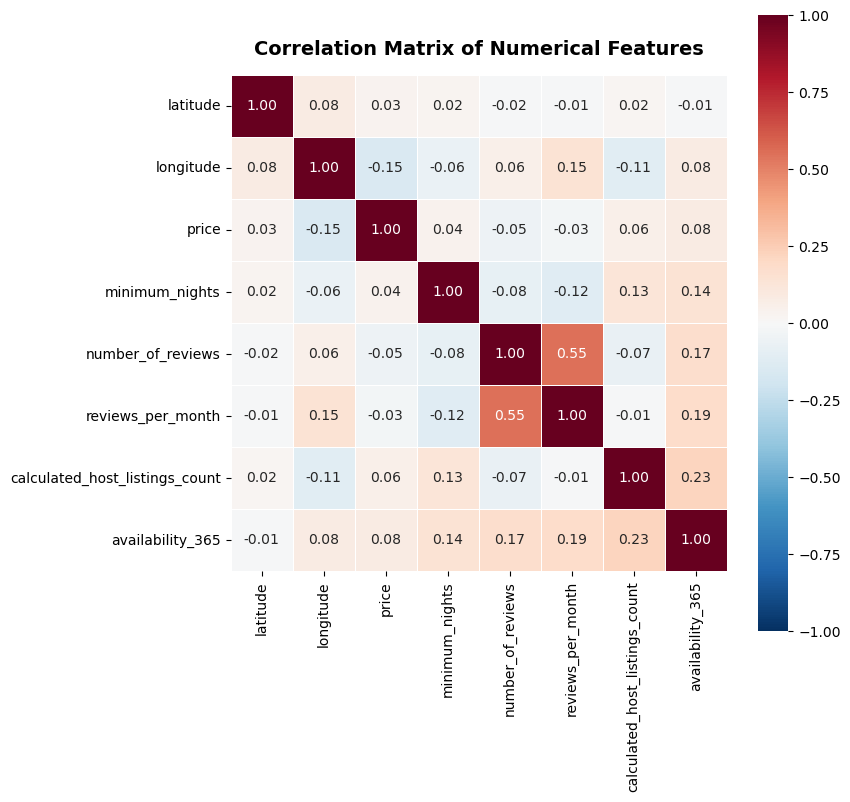

In [25]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8, 8))
sns.heatmap(corr, cmap="RdBu_r", vmax=1, vmin=-1, center=0, square=True, linewidths=.5, annot=True, fmt=".2f")
plt.title("Correlation Matrix of Numerical Features", fontsize=14, fontweight="bold", pad=15)
plt.show()

### 15. Conclusion and Next Steps

**Key Findings:**

- The price distribution is skewed to the right and contains outliers.
- Location (region) and room type appear to be the most significant variables influencing price. - Some columns (`reviews_per_month`, `last_review`) have missing values.

**Next steps (pre-modeling):**
- Filling in or removing missing values
- Handling outliers (filtering / log transformation)
- Converting categorical variables to numerical values ​​(encoding)
- Building the regression model